In [3]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from FastBEMT import BEMT, Environment, Propeller, Simulation
from FastBEMT.Utils.DataLoader import load_propeller_dict
import scienceplots

plt.style.use(['science', 'no-latex'])

In [ ]:
prop_name, blade_dict = load_propeller_dict('../Data/New/10x7E')[0]

environment = Environment(
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    p_ref=2e-5,
)
simulation = Simulation(
    revolutions=1,
    timesteps_per_revolution=100,
    device='cpu',
)

propeller = Propeller(
    geometry=blade_dict,
    environment=environment,
    simulation=simulation,
)

In [5]:
rpm = 7000
advance_ratios = np.arange(0.0, 1.0, 0.1)

bemt = BEMT(
    propeller=propeller,
    environment=environment,
    rpm=rpm,
    J=advance_ratios,
)

performance = bemt.performance.reset_index()
diameter = 2.0 * blade_dict['tip_radius']
performance['J'] = performance['v_inf'] / (
    performance['rpm'] / 60.0 * diameter
)
performance['efficiency'] = np.divide(
    performance['J'] * performance['thrust_coefficient'],
    2.0 * np.pi * performance['torque_coefficient'],
    out=np.zeros(len(performance)),
    where=performance['torque_coefficient'].to_numpy() > 0.0,
)

print(f'Propeller: {prop_name}')
performance

c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\neuralfoil\main.py:171: RuntimeWarning: divide by zero encountered in log
  (np.log(Re) - 12.5) / 3.5,
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\aerosandbox\numpy\surrogate_model_tools.py:253: RuntimeWarning: invalid value encountered in divide
  return x / (1 + _np.exp(-beta * x))
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\neuralfoil\main.py:227: RuntimeWarning: invalid value encountered in matmul
  x = w @ x + np.reshape(b, (-1, 1))
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\aerosandbox\library\aerodynamics\viscous.py:142: RuntimeWarning: divide by zero encountered in scalar divide
  return 0.074 / Re_L ** (1 / 5)
C:\Users\PusinoDavide\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:156: RuntimeWarning

Propeller: 10x7E


,rpm,v_inf,thrust,torque,thrust_coefficient,torque_coefficient,figure_of_merit,J,efficiency
0,7000.0,0.000000,7.980068,0.139295,0.114985,0.007902,0.626592,0.0,0.000000
1,7000.0,2.963333,7.907792,0.148744,0.113944,0.008438,0.578835,0.1,0.214916
2,7000.0,5.926667,7.580703,0.156075,0.109231,0.008854,0.517778,0.2,0.392700
3,7000.0,8.890000,6.965961,0.158948,0.100373,0.009017,0.447845,0.3,0.531496
4,7000.0,11.853333,5.955279,0.152045,0.085810,0.008625,0.370077,0.4,0.633350
5,7000.0,14.816667,4.600537,0.133019,0.066289,0.007546,0.287217,0.5,0.699066
6,7000.0,17.780000,3.168593,0.105326,0.045656,0.005975,0.207337,0.6,0.729688
7,7000.0,20.743333,1.542556,0.065862,0.022227,0.003736,0.112627,0.7,0.662767
8,7000.0,23.706667,-0.314808,0.015440,-0.004536,0.000876,NaN,0.8,-0.659406
9,7000.0,26.670000,-2.248466,-0.041706,-0.032398,-0.002366,NaN,0.9,0.000000


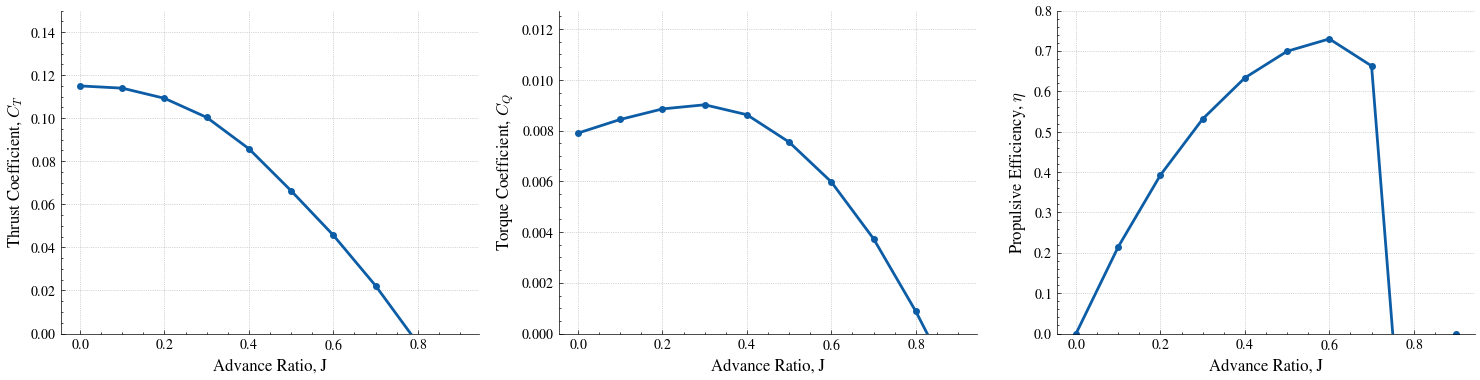

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(performance['J'], performance['thrust_coefficient'], 'o-', linewidth=2, markersize=4)
axes[0].set_xlabel('Advance Ratio, J', fontsize=12)
axes[0].set_ylabel('Thrust Coefficient, $C_T$', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=1.0)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].tick_params(top=False, right=False, which='both')
axes[0].set_ylim(0, 0.15)

axes[1].plot(performance['J'], performance['torque_coefficient'], 'o-', linewidth=2, markersize=4)
axes[1].set_xlabel('Advance Ratio, J', fontsize=12)
axes[1].set_ylabel('Torque Coefficient, $C_Q$', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=1.0)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].tick_params(top=False, right=False, which='both')
axes[1].set_ylim(0, 0.08 / 2 / np.pi)

axes[2].plot(performance['J'], performance['efficiency'], 'o-', linewidth=2, markersize=4)
axes[2].set_xlabel('Advance Ratio, J', fontsize=12)
axes[2].set_ylabel('Propulsive Efficiency, $\\eta$', fontsize=12)
axes[2].grid(True, linestyle=':', alpha=1.0)
axes[2].spines[['top', 'right']].set_visible(False)
axes[2].tick_params(top=False, right=False, which='both')
axes[2].set_ylim(0, 0.8)

plt.tight_layout()
figure_path = Path('../Figures/Validation/bemt_performance.pdf')
figure_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(figure_path, dpi=200)
plt.show()